In [156]:
#!/usr/bin/env python
# coding: utf-8

import numpy as np
import math
import numpy.ma as ma

from scipy.optimize import curve_fit
from scipy import interpolate
from scipy.integrate import trapz, simps, quad

from scipy.signal import find_peaks

from scipy.stats import poisson
from scipy.special import factorial
from scipy import stats

import pandas as pd

import matplotlib        as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors




NUMPY
# Exercice 1

In [9]:
#me
data = np.arange(0, 100, 1)
print(data)

moy = np.mean(data)
print(moy)

ecart_type = np.std(data)
print(ecart_type)

num = np.sum(np.abs(data - moy)**2)
den = len(data)

ecart_type2 = np.sqrt(num/den)
print(ecart_type2)

mask = (data > 50)
print(data[mask])



[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
49.5
28.86607004772212
28.86607004772212
[51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74
 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98
 99]


In [ ]:
#correction

a = np.arange(100)

mean = np.mean(a)
std  = np.std(a)
sup_50 = a[a > 50]

print(mean, std)
print(sup_50)


# Exercice 2

In [48]:
#me
from numpy import random

data = random.rand(10, 5)
print(data)


shape = np.shape(data)
print(shape[1])

mean_col = np.mean(data, axis=0)
mean_lin = np.mean(data, axis=1) 

print(np.max(data))

indexes = np.where(data==data.max())
print(indexes)

[[0.76216359 0.0961287  0.97362641 0.15626481 0.01283519]
 [0.84236131 0.50674723 0.89200758 0.17710626 0.56112378]
 [0.65318209 0.12308294 0.90416999 0.69208604 0.95197647]
 [0.27597568 0.36126695 0.71095648 0.29741937 0.5568672 ]
 [0.68001759 0.82919127 0.54411243 0.62544469 0.02803256]
 [0.70652906 0.8972741  0.79956538 0.08195915 0.4194493 ]
 [0.43415038 0.05519809 0.93733892 0.14454342 0.5310117 ]
 [0.19097736 0.9128037  0.94209874 0.86362473 0.75172284]
 [0.1279381  0.29433557 0.77729875 0.94472176 0.08891574]
 [0.07086692 0.95362704 0.53693064 0.19707987 0.64649988]]
5
0.9736264091853436
(array([0]), array([2]))


In [46]:
#correction
a = np.random.rand(10, 5)

mean_cols = np.mean(a, axis=0)
sum_rows  = np.sum(a, axis=1)
max_val   = np.max(a)
max_pos   = np.unravel_index(np.argmax(a), a.shape)

print(mean_cols)
print(sum_rows)
print(max_val, max_pos)


[0.44252718 0.55992516 0.52729567 0.55138973 0.48881767]
[2.1756943  1.8052249  2.32179207 3.02053265 1.87277933 3.01288852
 2.53520768 3.01889546 2.48462632 3.45191294]
0.9895720322801652 (5, 1)


# Exercice 3

In [60]:
#me
data = np.random.normal(loc=10, scale=2, size=1000)

mask = (data >= 8) & (data <= 12)

moy = np.mean(data[mask])
print(moy)

data[~mask] = np.nan

print(data[~mask])
print(data)

10.020650593050158
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan

In [59]:
#correction

mask = (data >= 8) & (data <= 12)

filtered = data[mask]
mean_filtered = np.mean(filtered)

data_nan = data.copy()
data_nan[~mask] = np.nan

print(mean_filtered)


9.98621744245106


# Exercice 4

In [72]:
#me
t = np.linspace(0, 1, 1000)
signal = np.sin(2*np.pi*5*t) + 0.5*np.random.normal(size=1000)

power = np.mean(signal)**2

max_ind = np.where(signal==signal.max())
print(max_ind)
print('instant max = ', t[max_ind])

sig_norm = signal/signal.sum()
print(signal, sig_norm.sum())

(array([48]),)
instant max =  [0.04804805]
[-8.79600613e-03  1.27830873e+00 -1.91774695e-01  1.50127866e-01
  7.30960116e-01 -1.54335044e-01  1.19614308e+00  2.05430098e-01
 -1.87514880e-01 -3.41280330e-02  5.93034464e-03  8.89210752e-01
  1.09736364e+00  1.04916775e-02  1.34236609e-01  6.32764368e-02
  3.09710620e-01  5.16180485e-01  6.96671829e-01  1.16231338e-01
  6.75849197e-01  3.75854676e-01  9.62581626e-01  1.56146215e+00
  9.03866853e-01  1.70010048e+00  8.54801168e-01  5.02724588e-01
  5.07092643e-01  1.39115559e+00  1.20848587e+00  1.89467374e+00
  1.10921273e+00  2.12328218e-01  5.57817837e-01  1.39593560e+00
  1.39167844e+00  7.78060984e-01  9.03209955e-01  7.26763134e-01
  9.59367359e-01  1.69312589e+00  6.81010156e-01  5.96663096e-01
  1.40514920e+00  1.32442722e+00 -1.16353509e-01  9.98849620e-01
  2.28739378e+00  2.99842545e-01  1.67897361e+00  1.37785405e+00
  6.97653970e-01  4.41961557e-01  1.69376855e+00  1.79026976e+00
  3.33918266e-01  1.48504143e+00  3.96609283e-0

In [ ]:
#correction
power = np.mean(signal**2)
t_max = t[np.argmax(signal)]

signal_norm = (signal - np.min(signal)) / (np.max(signal) - np.min(signal))

print(power, t_max)


# Exercice 5

In [92]:
#me
x = np.array([-1, -1, 0, 1, 1, 0, 0])
y = np.array([ 0, -1, -1, -1, 0, 1, 0])

charges = np.random.exponential(scale=10, size=(1000, 7))
print(np.shape(charges))


x_bary = []
y_bary = []
r = []
for i in range(len(charges)):
    x_evt = np.sum(x[:] * charges[i,:]) / charges[i,:].sum()
    y_evt = np.sum(y[:] * charges[i,:]) / charges[i,:].sum()
    x_bary.append(x_evt)
    y_bary.append(y_evt)
    r.append(np.sqrt(x_evt**2 + y_evt**2))

r = np.array(r)
mask = (r<0.5)

r05 = r[mask]

print(len(r05))

(1000, 7)
685


In [93]:
#correction
x_evt = np.sum(charges * x, axis=1) / np.sum(charges, axis=1)
y_evt = np.sum(charges * y, axis=1) / np.sum(charges, axis=1)

r_evt = np.sqrt(x_evt**2 + y_evt**2)

selected = r_evt < 0.5

print(np.sum(selected), "events sélectionnés")


685 events sélectionnés


PANDADATAFRAME
# Exercice 1

In [ ]:
Énoncé

Crée un DataFrame contenant :

event : numéro d’événement (0 → 999)

energy : loi exponentielle (scale=10)

x et y : positions uniformes entre -1 et 1

Affiche les 5 premières lignes

Calcule :

énergie moyenne

énergie max

Trace l’histogramme de l’énergie

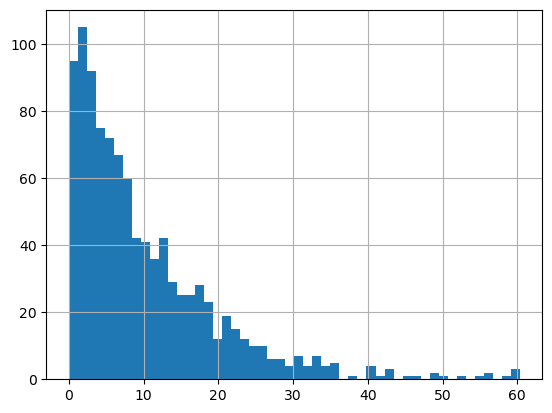

In [205]:
#me
event = np.arange(1000)
energy = np.random.exponential(scale=10, size=1000)
x = np.random.uniform(low=-1, high=1, size=1000)
y = np.random.uniform(low=-1, high=1, size=1000)

data = {'event': event, 'energy': energy, 'x': x, 'y': y}

df = pd.DataFrame(data)

df5 = df.head(5)

ene_mean = df.energy.mean()
ene_max = df.energy.max()

ene_hist = df.energy.hist(bins=50)




In [ ]:
#correction
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n = 1000

df = pd.DataFrame({
    'event': np.arange(n),
    'energy': np.random.exponential(scale=10, size=n),
    'x': np.random.uniform(-1, 1, size=n),
    'y': np.random.uniform(-1, 1, size=n)
})

print(df.head())

print("E moyenne =", df['energy'].mean())
print("E max =", df['energy'].max())

plt.figure()
plt.hist(df['energy'], bins=50)
plt.xlabel("Energy")
plt.ylabel("Counts")
plt.show()


# Exercice 2

In [ ]:
À partir du DataFrame précédent :

Sélectionne les événements avec energy > 15

Calcule leur fraction

Trace la carte (x, y) des événements sélectionnés

fraction d'evenements avec energie sup a 15 :  0.233


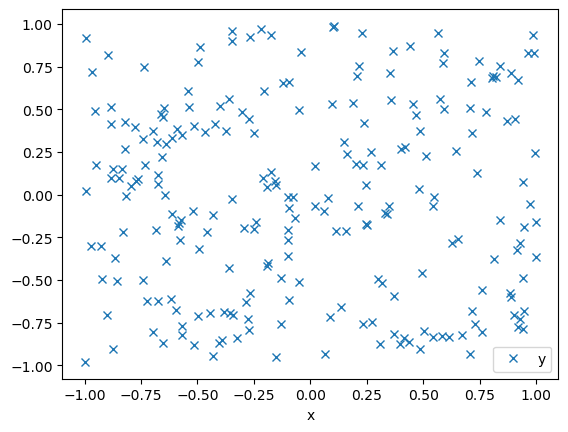

In [206]:
#me
enesup15 = df[df['energy'] > 15]


print("fraction d'evenements avec energie sup a 15 : ", len(enesup15)/len(df))

xyplot = enesup15[["x", "y"]]

plot = xyplot.plot(x='x', y='y', marker='x', linestyle='')

Fraction E > 15 = 0.215


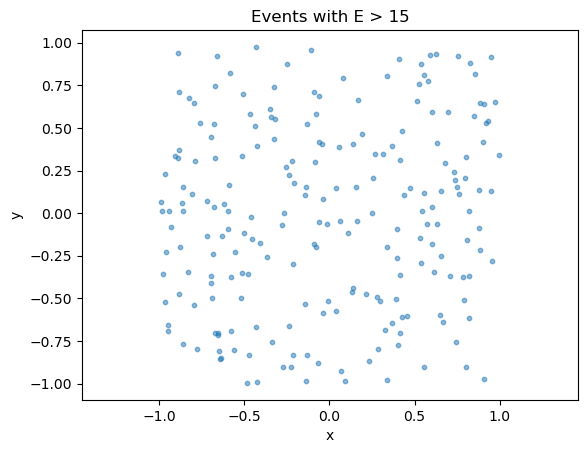

In [157]:
#correction 
df_sel = df[df.energy > 15]

fraction = len(df_sel) / len(df)
print("Fraction E > 15 =", fraction)


plt.scatter(df_sel.x, df_sel.y, s=10, alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Events with E > 15")
plt.axis("equal")
plt.show()


# Exercice 3

r_bin
(0.0513, 0.187]    10.383658
(0.187, 0.322]     10.424186
(0.322, 0.457]      8.485767
(0.457, 0.591]      9.769732
(0.591, 0.726]     11.141347
(0.726, 0.861]      9.678049
(0.861, 0.995]     10.293753
(0.995, 1.13]      10.798320
(1.13, 1.265]       9.630640
(1.265, 1.399]     10.987856
Name: energy, dtype: float64


Text(0, 0.5, 'ene mean')

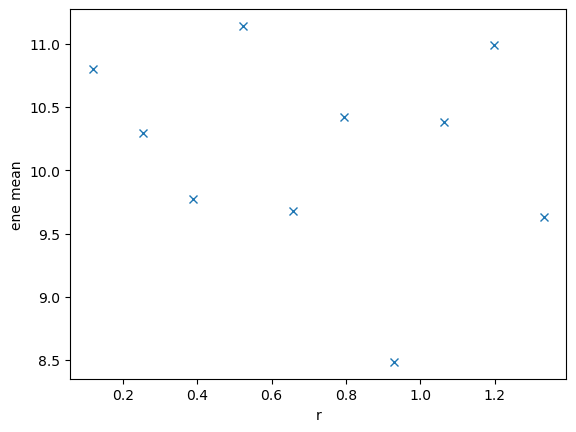

In [207]:
#me
df['r'] = np.sqrt(df.x**2 + df.y**2) 

df['r_bin'] = pd.cut(df['r'], bins=10)

mean_energy = df.groupby('r_bin').energy.mean()
print(mean_energy)
bin_centers = df['r_bin'].apply(lambda x: x.mid).unique()
plt.plot(bin_centers, mean_energy, marker='x', linestyle='')
plt.xlabel('r')
plt.ylabel('ene mean')



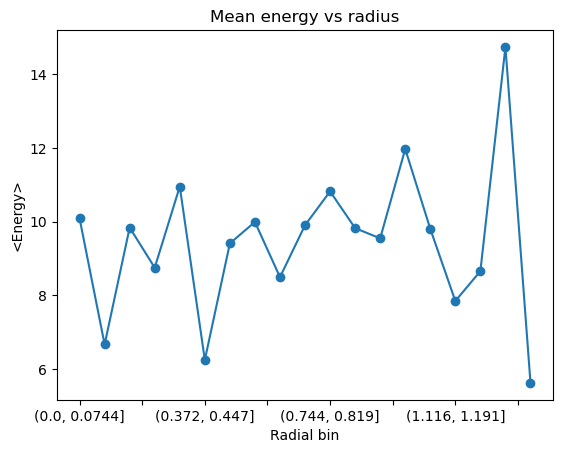

In [183]:
#correction
df['r'] = np.sqrt(df.x**2 + df.y**2)

bins = np.linspace(0, np.sqrt(2), 20)
df['r_bin'] = pd.cut(df.r, bins)

mean_energy = df.groupby('r_bin')['energy'].mean()

plt.figure()
mean_energy.plot(marker='o')
plt.xlabel("Radial bin")
plt.ylabel("<Energy>")
plt.title("Mean energy vs radius")
plt.show()


# Exercice 4

                      mean        std  size
r_bin                                      
(0.0513, 0.187]  10.383658   9.214226    41
(0.187, 0.322]   10.424186   9.496231    65
(0.322, 0.457]    8.485767   8.914223    76
(0.457, 0.591]    9.769732  10.026382   105
(0.591, 0.726]   11.141347  10.406689   125
(0.726, 0.861]    9.678049   8.690562   149
(0.861, 0.995]   10.293753   9.793316   205
(0.995, 1.13]    10.798320  11.957844   145
(1.13, 1.265]     9.630640   8.159417    66
(1.265, 1.399]   10.987856   8.715867    23


<ErrorbarContainer object of 3 artists>

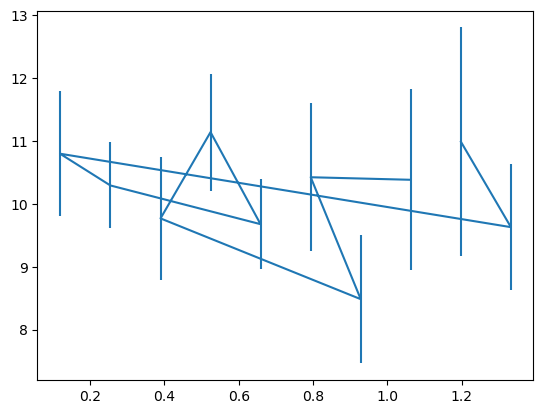

In [208]:
#me
ene_stats = df.groupby('r_bin')['energy'].agg(['mean', 'std', 'size'])
print(ene_stats)
bin_centers = df['r_bin'].apply(lambda x: x.mid).unique()

ene_stats['error'] = ene_stats['std'] / np.sqrt(ene_stats['size'])


plt.errorbar(bin_centers, ene_stats['mean'], yerr=ene_stats['error'])

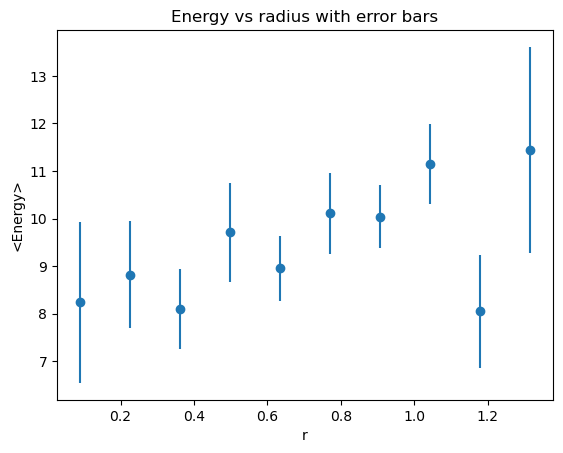

In [202]:
#correction
stats = df.groupby('r_bin')['energy'].agg(['mean', 'std', 'count'])

r_centers = [interval.mid for interval in stats.index]

plt.figure()
plt.errorbar(
    r_centers,
    stats['mean'],
    yerr=stats['std']/np.sqrt(stats['count']),
    fmt='o'
)
plt.xlabel("r")
plt.ylabel("<Energy>")
plt.title("Energy vs radius with error bars")
plt.show()


# Exercice 5

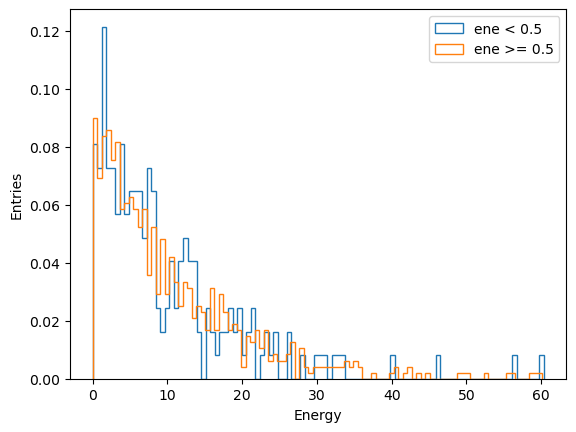

In [216]:
dfinf05 = df[df['r'] < 0.5]
dfsup05 = df[df['r'] >= 0.5]

ene1 = dfinf05['energy']
ene2 = dfsup05['energy']

plt.hist(ene1, bins=100, histtype='step', density=True, label='ene < 0.5')
plt.hist(ene2, bins=100, histtype='step', density=True, label='ene >= 0.5')
plt.xlabel('Energy')
plt.ylabel('Entries')
plt.legend()

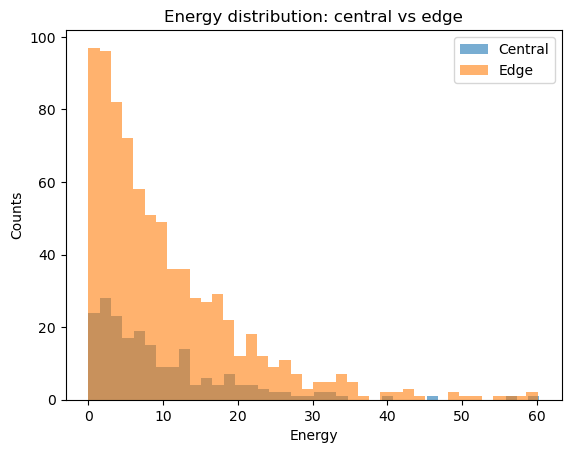

In [217]:
central = df[df.r < 0.5]
edge    = df[df.r >= 0.5]

plt.figure()
plt.hist(central.energy, bins=40, alpha=0.6, label='Central')
plt.hist(edge.energy, bins=40, alpha=0.6, label='Edge')
plt.xlabel("Energy")
plt.ylabel("Counts")
plt.legend()
plt.title("Energy distribution: central vs edge")
plt.show()


# Training Scipy + pd + plt

# Exercice 1

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_48274/640391998.py:16: RuntimeWarning: overflow encountered in exp
  return m * np.exp(-t * x) + b


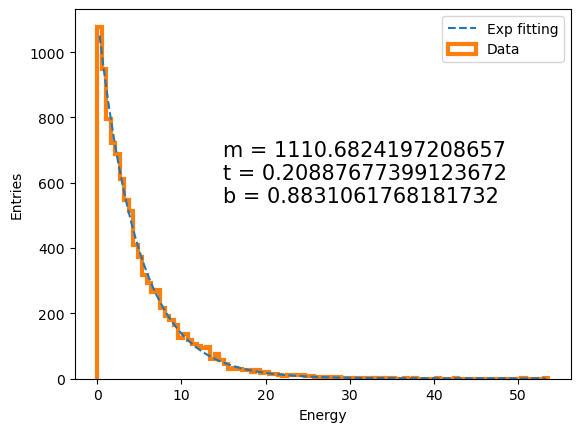

In [262]:
#me
n = 10000
energy = np.random.exponential(scale=5.0, size=n)
x = np.random.uniform(-1, 1, size=n)
y = np.random.uniform(-1, 1, size=n)

df = pd.DataFrame({'energy': energy, 'x': x, 'y': y})

ene = df['energy']

count, bin_edges = np.histogram(ene, bins=100)
bincenter = (bin_edges[:-1] + bin_edges[1:]) / 2
#plt.plot(bincenter, count)

def func(x, m, t, b):
    return m * np.exp(-t * x) + b

p0 = (10, 10, 10)
popt, pcov = curve_fit(func, bincenter, count, p0)
m, t, b = popt

plt.plot(bincenter, func(bincenter, m, t, b), '--', label="Exp fitting" )
plt.hist(ene, 100, histtype='step', linewidth=3, label='Data')
plt.text(15, 540, f'm = {m}\nt = {t}\nb = {b}', fontsize=15)
plt.xlabel('Energy')
plt.ylabel('Entries')
plt.legend()




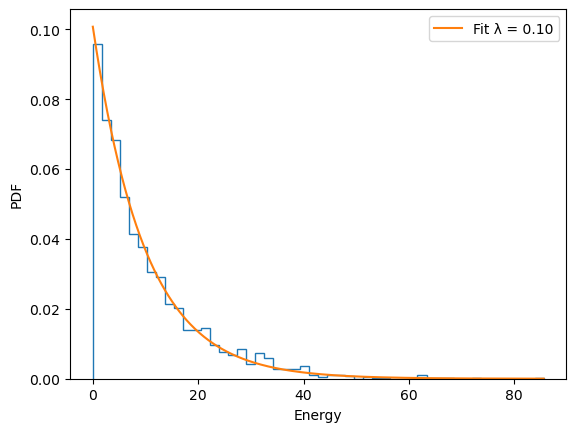

In [274]:
#correction
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

np.random.seed(0)

N = 2000
df = pd.DataFrame({
    'energy': np.random.exponential(scale=10, size=N),
    'x': np.random.uniform(-1, 1, size=N),
    'y': np.random.uniform(-1, 1, size=N)
})

counts, bins, _ = plt.hist(df['energy'], bins=50, density=True, histtype='step')
bin_centers = 0.5 * (bins[1:] + bins[:-1])

def expo(E, lamb):
    return lamb * np.exp(-lamb * E)

popt, _ = curve_fit(expo, bin_centers, counts)
lamb_fit = popt[0]

E = np.linspace(0, df['energy'].max(), 500)
plt.plot(E, expo(E, lamb_fit), label=f'Fit λ = {lamb_fit:.2f}')
plt.xlabel('Energy')
plt.ylabel('PDF')
plt.legend()
plt.show()


# Exercice 2

Text(0, 0.5, 'Energy')

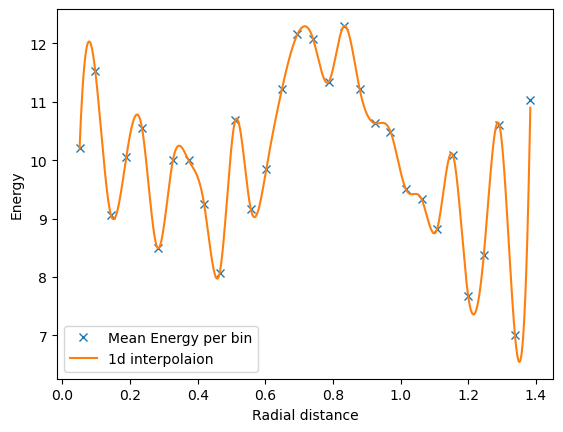

In [294]:
#me
df['r'] = np.sqrt(df['x']**2 + df['y']**2)
df['r_bin'] = pd.cut(df['r'], bins=30)

ene_stats = df.groupby('r_bin')['energy'].agg(['mean', 'std', 'size'])
r_centers = [interval.mid for interval in ene_stats.index]

spline = interp1d(r_centers, ene_stats['mean'], kind='cubic')
xspline = np.arange(np.min(r_centers), np.max(r_centers), 0.001)
yspline = spline(xspline)

plt.plot(r_centers, ene_stats['mean'], linestyle='', marker='x', label='Mean Energy per bin')
plt.plot(xspline, yspline, label='1d interpolaion')

plt.legend()
plt.xlabel('Radial distance')
plt.ylabel('Energy')


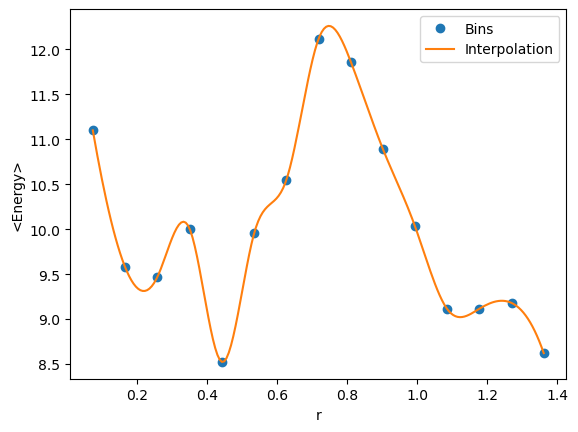

In [293]:
#correction
from scipy.interpolate import interp1d

df['r'] = np.sqrt(df.x**2 + df.y**2)
df['r_bin'] = pd.cut(df['r'], bins=15)

mean_energy = df.groupby('r_bin')['energy'].mean()
bin_centers = [interval.mid for interval in mean_energy.index]

interp = interp1d(bin_centers, mean_energy, kind='cubic')
r_fine = np.linspace(min(bin_centers), max(bin_centers), 200)

plt.plot(bin_centers, mean_energy, 'o', label='Bins')
plt.plot(r_fine, interp(r_fine), '-', label='Interpolation')
plt.xlabel('r')
plt.ylabel('<Energy>')
plt.legend()
plt.show()


# Exercice 3

         energy         x         y         r           r_bin
1     12.559308 -0.047832  0.133037  0.141374   (0.12, 0.166]
5     10.381593 -0.394190 -0.241864  0.462476  (0.442, 0.488]
22     6.189295 -0.322971  0.358300  0.482379  (0.442, 0.488]
23    15.165360  0.154992  0.321038  0.356494   (0.35, 0.396]
30     3.072804  0.143100  0.215410  0.258610  (0.258, 0.304]
...         ...       ...       ...       ...             ...
1981  12.766991 -0.275482  0.416566  0.499418  (0.488, 0.534]
1982   3.537795  0.116276  0.056573  0.129308   (0.12, 0.166]
1985   4.188944  0.022206  0.456957  0.457496  (0.442, 0.488]
1993  10.798060 -0.190640  0.200138  0.276404  (0.258, 0.304]
1999   6.966997 -0.383323 -0.320899  0.499912  (0.488, 0.534]

[391 rows x 5 columns]


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_48274/3924894903.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rinf05['r_bin_inf05'] = pd.cut(rinf05['r'], bins=100)


KeyError: 'energy'

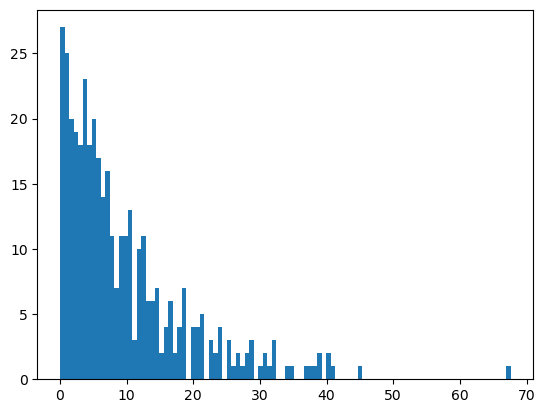

In [312]:
rinf05 = df[df['r'] < 0.5]
print(rinf05)
rsup05 = df[df['r'] >= 0.5]

ene_inf05 = rinf05['energy']
ene_sup05 = rsup05['energy']

rinf05['r_bin_inf05'] = pd.cut(rinf05['r'], bins=100)
rinf05_stats = rinf05.groupby('r_bin_inf05')['energy'].agg(['mean', 'std', 'size', 'max'])

r_inf05_centers = [interval.mid for interval in rinf05_stats.index]

plt.hist(ene_inf05, bins=100)
plt.errorbar(r_inf05_centers, rinf05_stats['energy'])



plt.hist(ene_inf05, bins=100, density=True)
plt.hist(ene_sup05, bins=100, density=True)



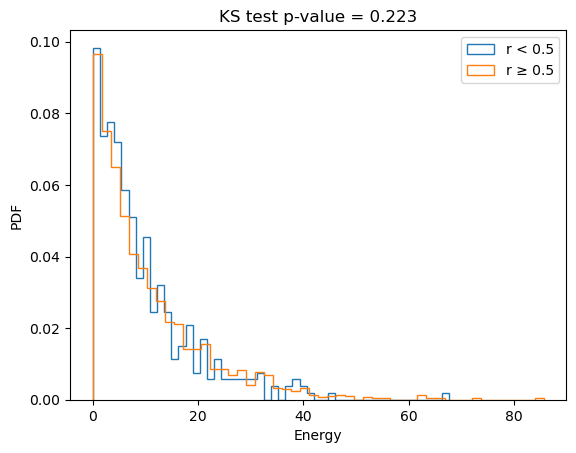

In [313]:
from scipy.stats import ks_2samp

ene_central = df[df['r'] < 0.5]['energy']
ene_periph = df[df['r'] >= 0.5]['energy']

ks_stat, pval = ks_2samp(ene_central, ene_periph)

plt.hist(ene_central, bins=50, density=True, histtype='step', label='r < 0.5')
plt.hist(ene_periph, bins=50, density=True, histtype='step', label='r ≥ 0.5')
plt.title(f'KS test p-value = {pval:.3f}')
plt.xlabel('Energy')
plt.ylabel('PDF')
plt.legend()
plt.show()


# Exercice 4

energy_bins
(-0.0819, 0.86]     12.845233
(0.86, 1.716]       12.767145
(1.716, 2.572]      11.357817
(2.572, 3.428]      11.180340
(3.428, 4.284]      11.045361
                      ...    
(81.33, 82.186]      0.000000
(82.186, 83.042]     0.000000
(83.042, 83.898]     0.000000
(83.898, 84.754]     0.000000
(84.754, 85.61]      1.000000
Name: size, Length: 100, dtype: float64


(array([165., 163., 129., 125., 122., 112.,  91.,  87.,  82.,  60.,  66.,
         63.,  49.,  56.,  58.,  42.,  30.,  43.,  37.,  32.,  26.,  22.,
         22.,  26.,  29.,  21.,  17.,  16.,  10.,  16.,  17.,   6.,  10.,
         19.,   8.,   6.,  12.,  13.,  10.,  10.,   6.,   4.,   4.,   6.,
          2.,   8.,   2.,  10.,   1.,   3.,   0.,   2.,   3.,   1.,   4.,
          0.,   2.,   1.,   0.,   0.,   2.,   0.,   0.,   1.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   3.,   1.,   1.,   0.,   1.,
          0.,   0.,   1.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([3.67411239e-03, 8.59740447e-01, 1.71580678e+00, 2.57187312e+00,
        3.42793945e+00, 4.28400578e+00, 5.14007212e+00, 5.99613845e+00,
        6.85220479e+00, 7.70827112e+00, 8.56433746e+00, 9.42040379e+00,
        1.02764701e+01, 1.11325365e+01, 1.19886028e+01, 1.28446691e+01,
        1.37007355e+01, 1.4556

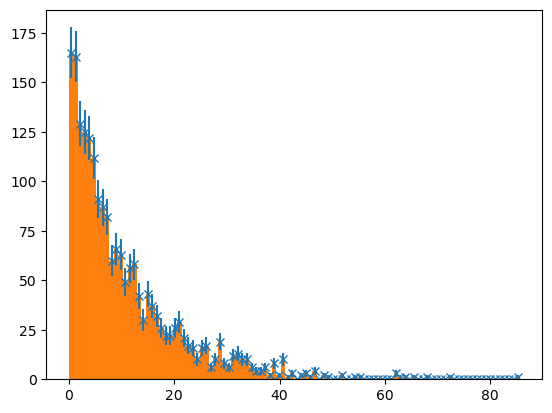

In [347]:
#me
df['energy_bins'] = pd.cut(df['energy'], bins=100)
enebin_stats = df.groupby('energy_bins')['energy'].agg(['mean', 'std', 'size'])

enebin_centers = [interval.mid for interval in enebin_stats.index]

yerr = np.sqrt(enebin_stats['size'])
print(yerr)

plt.errorbar(enebin_centers, enebin_stats['size'], 
             yerr=yerr, 
             linestyle='', 
             marker='x')
plt.hist(df['energy'], bins=100)







In [368]:
#me
from matplotlib.colors import LogNorm
binval = 30

df['x_bins'] = pd.cut(df['x'], bins=binval)
x_stats = df.groupby('x_bins')['energy'].agg(['mean', 'std', 'size', 'sum'])

df['y_bins'] = pd.cut(df['y'], bins=binval)
y_stats = df.groupby('y_bins')['energy'].agg(['mean', 'std', 'size', 'sum'])

enecum = x_stats['sum'] + y_stats['sum']

xbin_centers = [interval.mid for interval in x_stats.index]
ybin_centers = [interval.mid for interval in y_stats.index]

plt.errorbar(xbin_centers, ybin_centers, enecum)


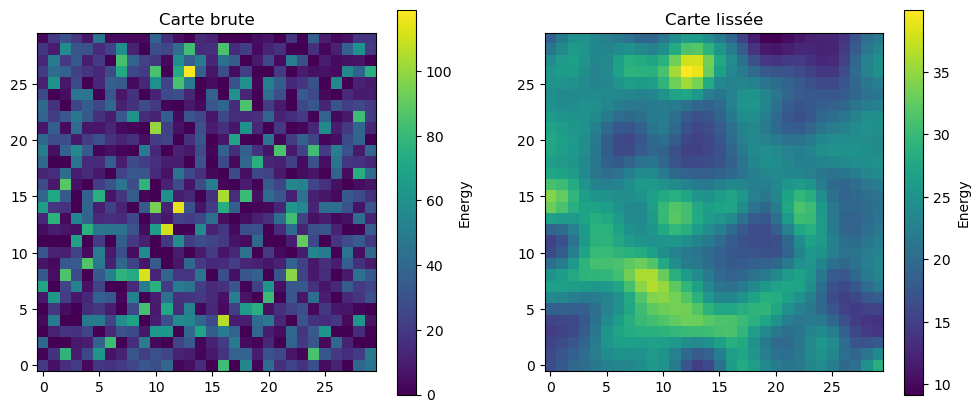

In [367]:
#correction
from scipy.ndimage import gaussian_filter

H, xedges, yedges = np.histogram2d(
    df['x'], df['y'],
    bins=30,
    weights=df['energy']
)

H_smooth = gaussian_filter(H, sigma=1.5)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(H.T, origin='lower')
plt.title('Carte brute')
plt.colorbar(label='Energy')

plt.subplot(1, 2, 2)
plt.imshow(H_smooth.T, origin='lower')
plt.title('Carte lissée')
plt.colorbar(label='Energy')

plt.show()


# Exercice 5

In [370]:
#correction
from scipy.optimize import minimize

energies = df['energy'].values
print(energies)

def neg_log_likelihood(lamb):
    if lamb <= 0:
        return np.inf
    return -np.sum(np.log(lamb) - lamb * energies)

result = minimize(neg_log_likelihood, x0=[0.1])
lamb_mle = result.x[0]

print("λ MLE :", lamb_mle)
print("λ fit histogramme :", lamb_fit)


[ 7.95874508 12.55930763  9.23223146 ...  6.5413381  10.32442702
  6.96699745]
λ MLE : 0.09663743475364871
λ fit histogramme : 0.1007501717425956


/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


# Matplotlib

# Exercice 1
Données

Génère 10 000 valeurs suivant une loi exponentielle (scale=5)

Travail demandé

Tracer un histogramme de l’énergie

Choisir un nombre de bins pertinent

Normaliser l’histogramme

Ajouter :

labels d’axes

un titre

une grille discrète

Afficher la moyenne et l’écart-type sur la figure (texte)

Compétences travaillées

plt.hist

normalisation (density=True)

annotations (plt.text)

lisibilité

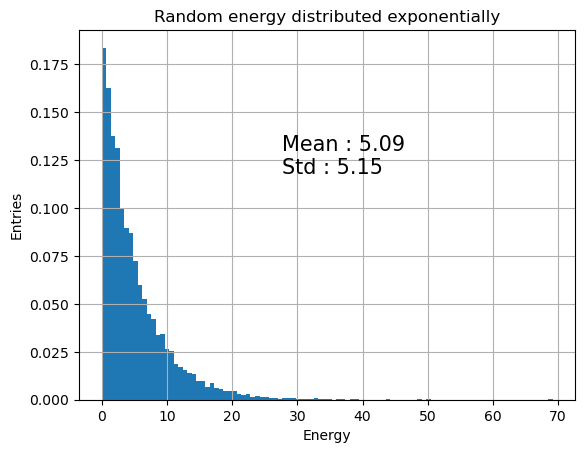

In [391]:
energy = np.random.exponential(scale=5, size=10000)

mean = np.mean(energy)
std = np.std(energy)


plt.hist(energy, bins = 100, density=True)
xmin, xmax = plt.xlim()
plt.text((xmin + xmax)*0.40, 1.18e-1, f'Mean : {mean:,.2f}\nStd : {std:,.2f}', fontsize=15)
plt.xlabel('Energy')
plt.ylabel('Entries')
plt.title('Random energy distributed exponentially')
plt.grid(True)


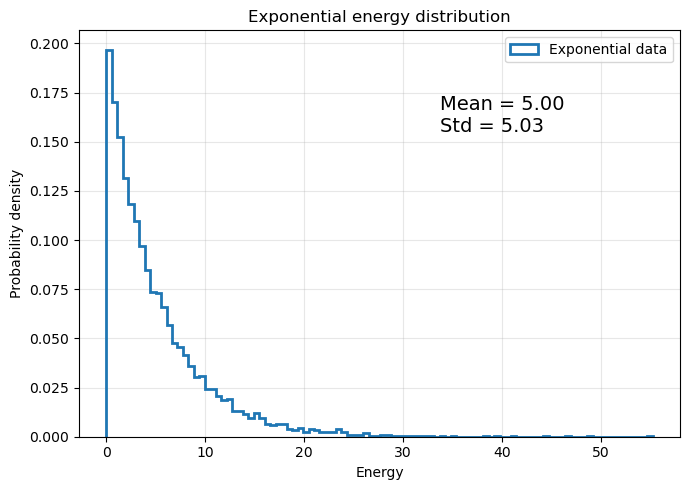

In [392]:
#correction
energy = np.random.exponential(scale=5, size=10000)

mean = np.mean(energy)
std  = np.std(energy)

plt.figure(figsize=(7, 5))

plt.hist(
    energy,
    bins=100,
    density=True,
    histtype='step',
    linewidth=2,
    label='Exponential data'
)

plt.text(
    0.60, 0.75,
    f'Mean = {mean:.2f}\nStd = {std:.2f}',
    transform=plt.gca().transAxes,
    fontsize=14
)

plt.xlabel('Energy')
plt.ylabel('Probability density')
plt.title('Exponential energy distribution')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Exercice 2
Génère 5 000 événements :

x, y ∈ [-1, 1]

énergie exponentielle

Travail demandé

Scatter plot de (x, y)

Utiliser l’énergie comme :

couleur

taille des points

Ajouter une colorbar

Fixer un aspect ratio égal

Limiter la plage de couleurs pour éviter les outliers

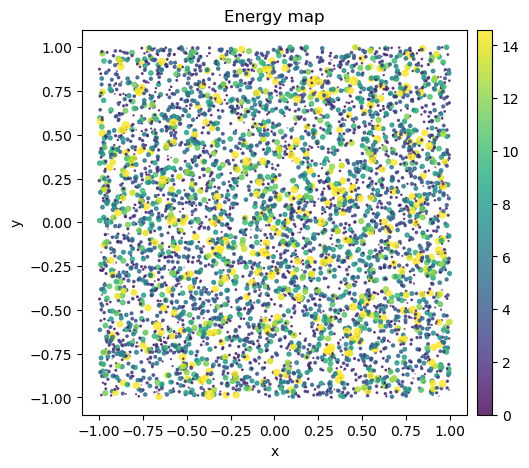

In [435]:
#me
energy = np.random.exponential(scale=5, size=5000)
x = np.random.uniform(-1, 1, size=5000)
y = np.random.uniform(-1, 1, size=5000)

df = pd.DataFrame({'energy': energy, 'x': x, 'y': y})

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

vmin = 0
vmax = np.percentile(df['energy'], 95)

plot = ax.scatter(df['x'], df['y'],  c=df['energy'], cmap='viridis', s=df['energy'], alpha=0.8, vmin=vmin, vmax=vmax)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Energy map")
ax.set_aspect('equal')

bbox = ax.get_position()
height = bbox.height
bottom = bbox.y0


cax = fig.add_axes([
    bbox.x1 + 0.02,  # un peu à droite du plot
    bottom,
    0.03,           # largeur colorbar
    height
])

cbar = plt.colorbar(plot, cax=cax)


plt.show()




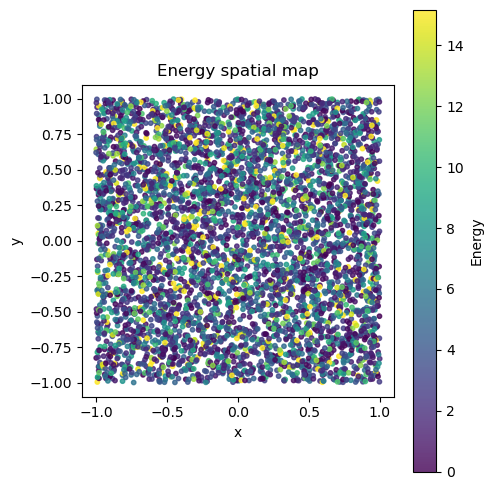

In [421]:
#correction
energy = np.random.exponential(scale=5, size=5000)
x = np.random.uniform(-1, 1, size=5000)
y = np.random.uniform(-1, 1, size=5000)

df = pd.DataFrame({'energy': energy, 'x': x, 'y': y})

fig, ax = plt.subplots(figsize=(5, 5))

# Limitation de la plage de couleurs (éviter les outliers)
vmin = 0
vmax = np.percentile(df['energy'], 95)

sc = ax.scatter(
    df['x'],
    df['y'],
    c=df['energy'],
    cmap='viridis',
    s=10,
    alpha=0.8,
    vmin=vmin,
    vmax=vmax
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Energy spatial map")

# Aspect ratio égal
ax.set_aspect('equal')

# Colorbar liée AU scatter
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Energy")

plt.tight_layout()
plt.show()


        energy         x         y         r           r_bin
0     4.490533 -0.955783 -0.018758  0.955967  (0.849, 0.987]
1     2.101465 -0.213167 -0.806200  0.833906  (0.711, 0.849]
2     9.504035  0.805164 -0.172921  0.823524  (0.711, 0.849]
3     9.720002  0.291014 -0.790301  0.842179  (0.711, 0.849]
4     0.706909  0.258176  0.226154  0.343221  (0.296, 0.434]
...        ...       ...       ...       ...             ...
4995  0.471682  0.071620  0.654332  0.658240  (0.572, 0.711]
4996  2.015552 -0.614954  0.543981  0.821026  (0.711, 0.849]
4997  0.629969 -0.974172 -0.199195  0.994329  (0.987, 1.125]
4998  7.488240 -0.040548  0.501744  0.503380  (0.434, 0.572]
4999  5.993128 -0.931521 -0.670825  1.147928  (1.125, 1.264]

[5000 rows x 5 columns]                     mean       std  size
r_bin                                   
(0.018, 0.158]  5.211958  4.943373   121
(0.158, 0.296]  5.270383  5.125759   231
(0.296, 0.434]  5.605546  6.108887   404
(0.434, 0.572]  4.761085  4.448731   5

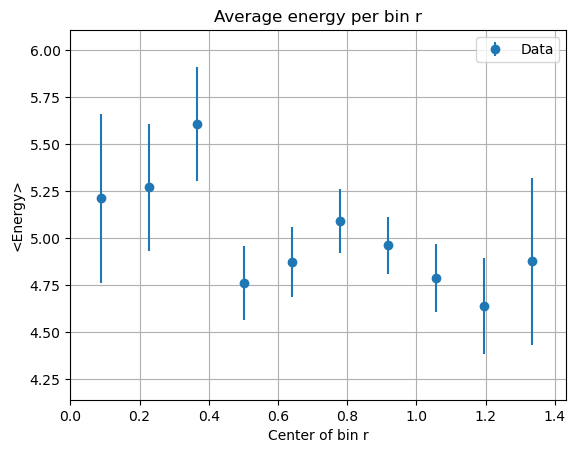

In [464]:
#me
df['r'] = np.sqrt(df['x']**2 + df['y']**2)

df['r_bin'] = pd.cut(df['r'], bins=10)
ene_stats = df.groupby('r_bin')['energy'].agg(['mean', 'std', 'size'])

r_centers = [interval.mid for interval in ene_stats.index]
yerr = ene_stats['std']/np.sqrt(ene_stats['size'])

plt.errorbar(r_centers, ene_stats['mean'], yerr=yerr, linestyle='', marker='o', label='Data')
plt.xlabel('Center of bin r')
plt.ylabel('<Energy>')
plt.xlim(0, np.max(r_centers) + 0.1)
plt.ylim(ene_stats['mean'].min() - 0.5, ene_stats['mean'].max() + 0.5)
plt.title('Average energy per bin r')
plt.grid()
plt.legend()
print(df, ene_stats)




# Exercice 4
Données

Même dataset (x, y, energy)

Travail demandé

Construire une carte 2D de l’énergie :

histogramme 2D pondéré

Afficher la carte brute

Appliquer un lissage spatial

Afficher la carte lissée

Ajouter :

colorbar

labels

titre

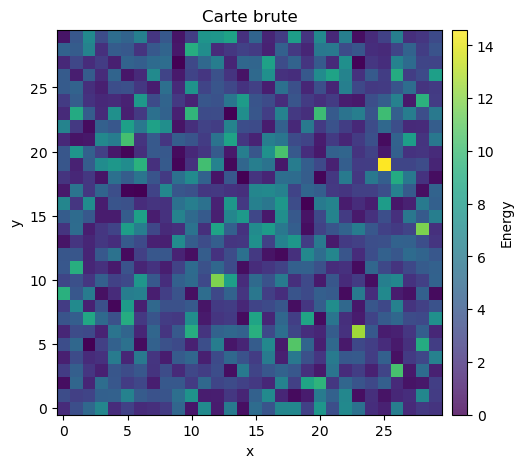

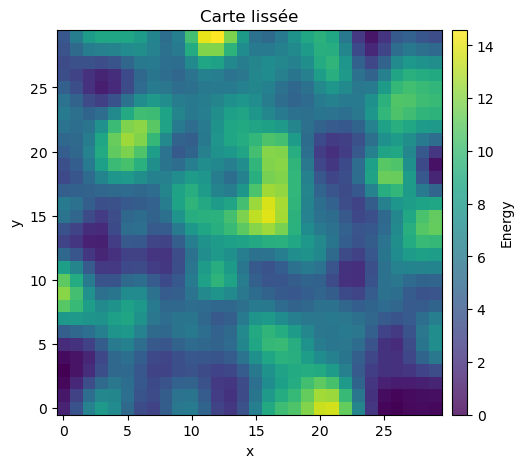

In [499]:
#me
from scipy.ndimage import gaussian_filter

H, xedges, yedges = np.histogram2d(df['x'], df['y'], bins=30, weights=df['energy'])

H_smooth = gaussian_filter(H, sigma=1.5)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax.imshow(H, origin='lower')
ax.set_title('Carte brute')
ax.set_xlabel('x')
ax.set_ylabel('y')
bbox = ax.get_position()
height = bbox.height
bottom = bbox.y0

cax = fig.add_axes([
    bbox.x1 + 0.02,  # un peu à droite du plot
    bottom,
    0.03,           # largeur colorbar
    height
])

cbar = plt.colorbar(plot, cax=cax)
cbar.set_label('Energy')
plt.show()

fig1, ax1 = plt.subplots(1, 1, figsize=(5, 5))

ax1.imshow(H_smooth, origin='lower')
ax1.set_title('Carte lissée')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
bbox = ax1.get_position()
height = bbox.height
bottom = bbox.y0

cax = fig1.add_axes([
    bbox.x1 + 0.02,  # un peu à droite du plot
    bottom,
    0.03,           # largeur colorbar
    height
])

cbar = plt.colorbar(plot, cax=cax)
cbar.set_label('Energy')

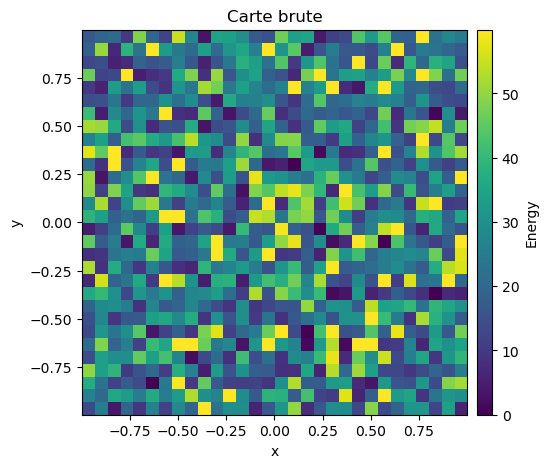

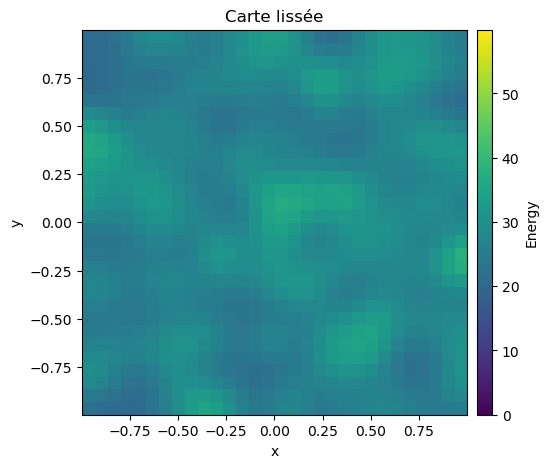

In [500]:
#correction
from scipy.ndimage import gaussian_filter

# Histogramme 2D pondéré
H, xedges, yedges = np.histogram2d(
    df['x'], df['y'],
    bins=30,
    weights=df['energy']
)

# Lissage spatial
H_smooth = gaussian_filter(H, sigma=1.5)

# Étendue spatiale correcte
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

vmax = np.percentile(H, 95)

# --- Carte brute ---
fig, ax = plt.subplots(figsize=(5, 5))

im = ax.imshow(
    H.T,
    origin='lower',
    extent=extent,
    cmap='viridis',
    vmin=0,
    vmax=vmax
)

ax.set_title('Carte brute')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')

fig.canvas.draw()
bbox = ax.get_position()

cax = fig.add_axes([bbox.x1 + 0.02, bbox.y0, 0.03, bbox.height])
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Energy')

plt.show()

# --- Carte lissée ---
fig, ax = plt.subplots(figsize=(5, 5))

im2 = ax.imshow(
    H_smooth.T,
    origin='lower',
    extent=extent,
    cmap='viridis',
    vmin=0,
    vmax=vmax
)

ax.set_title('Carte lissée')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')

fig.canvas.draw()
bbox = ax.get_position()

cax = fig.add_axes([bbox.x1 + 0.02, bbox.y0, 0.03, bbox.height])
cbar = plt.colorbar(im2, cax=cax)
cbar.set_label('Energy')

plt.show()


# Exercice 5

Données

Réutiliser tout ce que tu as fait avant

Travail demandé

Créer une figure avec 4 panneaux :

Histogramme énergie

Scatter (x, y) coloré par énergie

⟨E⟩(r) avec erreurs

Carte 2D lissée

Contraintes :

même style graphique partout

pas de chevauchement

titres cohérents

axes alignés

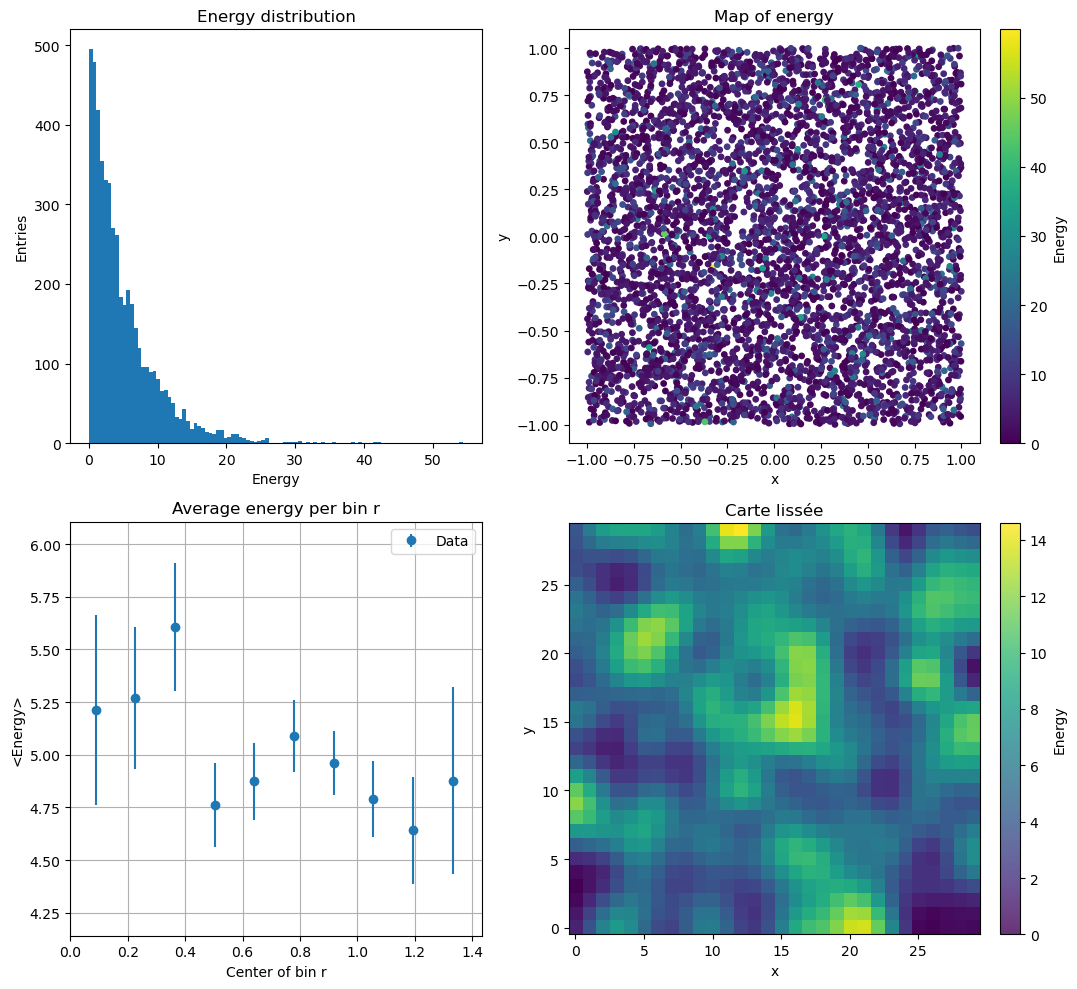

In [529]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

#1st plot
ax[0,0].hist(df['energy'], bins=100)
ax[0,0].set_xlabel('Energy')
ax[0,0].set_ylabel('Entries')
ax[0,0].set_title('Energy distribution')

#2nd plot
ax[0,1].scatter(df['x'], df['y'], c=df['energy'], s=15)
ax[0,1].set_xlabel('x')
ax[0,1].set_ylabel('y')
ax[0,1].set_title('Map of energy')

#3rd plot
ax[1,0].errorbar(r_centers, ene_stats['mean'], yerr=yerr, linestyle='', marker='o', label='Data')
ax[1,0].set_xlabel('Center of bin r')
ax[1,0].set_ylabel('<Energy>')
ax[1,0].set_xlim(0, np.max(r_centers) + 0.1)
ax[1,0].set_ylim(ene_stats['mean'].min() - 0.5, ene_stats['mean'].max() + 0.5)
ax[1,0].set_title('Average energy per bin r')
ax[1,0].grid()
ax[1,0].legend()

#4th plot
ax[1,1].imshow(H_smooth, origin='lower')
ax[1,1].set_title('Carte lissée')
ax[1,1].set_xlabel('x')
ax[1,1].set_ylabel('y')

plt.tight_layout()

bbox = ax[0,1].get_position()
cax = fig.add_axes([bbox.x1 + 0.02, bbox.y0, 0.02, bbox.height])
cbar = plt.colorbar(im2, cax=cax)
cbar.set_label('Energy')

bbox1 = ax[1,1].get_position()
height = bbox1.height
bottom = bbox1.y0

cax1 = fig.add_axes([
    bbox1.x1 + 0.02,  # un peu à droite du plot
    bottom,
    0.02,           # largeur colorbar
    height
])

cbar1 = plt.colorbar(plot, cax=cax1)
cbar1.set_label('Energy')


# advanced exercices

# Exercice 1


In [ ]:
Contexte

Tu observes un signal temporel dont la moyenne change à un instant inconnu.

Données

5 000 points

bruit gaussien

la moyenne change brutalement vers l’indice ~2500

Travail demandé

Simuler le signal

Mettre les données dans un DataFrame avec :

time

signal

Calculer une moyenne glissante

Détecter automatiquement la rupture

Visualiser :

signal brut

moyenne glissante

position de la rupture


      index     t    signal       MAW
0      2459  2459 -0.095165  0.573140
1      2460  2460 -0.939160  0.608216
2      2461  2461  0.628805  0.646969
3      2462  2462 -1.344316  0.710046
4      2463  2463 -0.549253  0.774389
...     ...   ...       ...       ...
2536   4995  4995  4.973090  4.975516
2537   4996  4996  5.583658  4.973135
2538   4997  4997  3.077978  4.943649
2539   4998  4998  4.680875  4.930851
2540   4999  4999  4.641560  4.909254

[2541 rows x 4 columns]


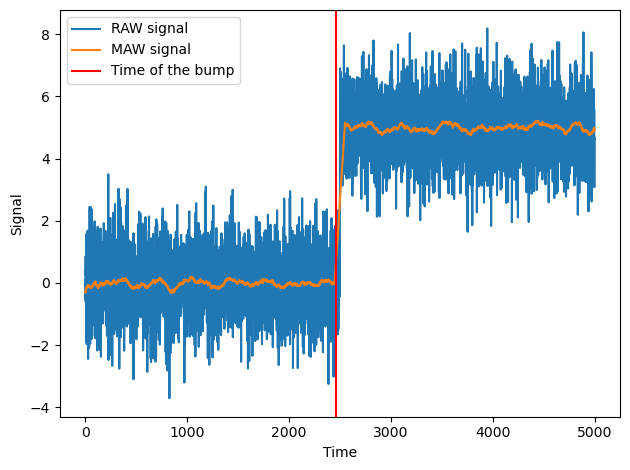

In [570]:
#me
sample1 = np.random.normal(0, 1, size=2500)
sample2 = np.random.normal(5, 1, size=2500)
signal = np.concatenate([sample1, sample2])
t = np.arange(0, 5000, 1)
plt.plot(t, signal, label='RAW signal')

df = pd.DataFrame({'t': t ,'signal': signal})

size_window = 50

MAW_store = []
for i in range(len(df['signal'])):
    if i < size_window:
        dfinfsize_window = df[(df['t'] < i)]
        dfsup = df[(df['t'] <= i + size_window) & (df['t'] > i)]
        sum_window = dfinfsize_window['signal'].sum() + df['signal'][i] + dfsup['signal'].sum()
        MAW = sum_window/(len(dfinfsize_window) + len(dfsup) + 1)
        
    if (np.max(t) - i) < size_window:
        dfsupsize_window = df[df['t'] > i]
        dfinf = df[(df['t'] >= i - size_window) & (df['t'] < i)]
        sum_window = dfinf['signal'].sum() + df['signal'][i] + dfsupsize_window['signal'].sum()
        MAW = sum_window/(len(dfsupsize_window) + len(dfinf) + 1)
        
    else:
        dfinf = df[(df['t'] >= i - size_window) & (df['t'] < i)]
        dfsup = df[(df['t'] <= i + size_window) & (df['t'] > i)]
        sum_window = dfinf['signal'].sum() + dfsup['signal'].sum() + df['signal'][i]
        MAW = sum_window/(len(dfinf) + len(dfsup) + 1)
    MAW_store.append(MAW)

df['MAW'] = MAW_store
bump = df[df['MAW'] >= 0.5].reset_index()
print(bump)
plt.plot(df['t'], df['MAW'], label='MAW signal')
plt.axvline(bump['t'][0], label='Time of the bump', color='red')
plt.xlabel('Time')
plt.ylabel('Signal')
plt.legend()
plt.tight_layout()
        

In [ ]:
#correction
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1) Génération du signal
# ===============================
np.random.seed(0)

sample1 = np.random.normal(0, 1, size=2500)
sample2 = np.random.normal(5, 1, size=2500)

signal = np.concatenate([sample1, sample2])
t = np.arange(len(signal))

# ===============================
# 2) Moyenne glissante (MAW) avec NumPy
# ===============================
size_window = 50

window = np.ones(2 * size_window + 1)
window /= window.sum()   # normalisation

MAW = np.convolve(signal, window, mode='same')

# ===============================
# 3) Détection du bump
# ===============================
threshold = 0.5
bump_index = np.argmax(MAW > threshold)

# Alternative plus robuste (commentée)
# dMAW = np.gradient(MAW)
# bump_index = np.argmax(dMAW)

# ===============================
# 4) Visualisation
# ===============================
plt.figure(figsize=(10, 4))

plt.plot(t, signal, alpha=0.4, label='RAW signal')
plt.plot(t, MAW, lw=2, label='Moving Average')
plt.axvline(bump_index, color='red', linestyle='--', label='Detected change')

plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('Moving Average Window (NumPy)')
plt.legend()
plt.tight_layout()
plt.show()


# Exercice B
Deux variables ne sont pas linéairement corrélées, mais sont liées.

Données

x∼U(0,10)

y=sin⁡(x)+bruit

Travail demandé

Construire un DataFrame

Calculer :

corrélation de Pearson

corrélation de Spearman

Visualiser :

scatter

binned mean de y(x)

Interpréter la différence entre les corrélations

PearsonRResult(statistic=-0.08381907807775203, pvalue=2.922924283237237e-09)
SpearmanrResult(correlation=-0.09931285952451437, pvalue=1.948387680943426e-12)


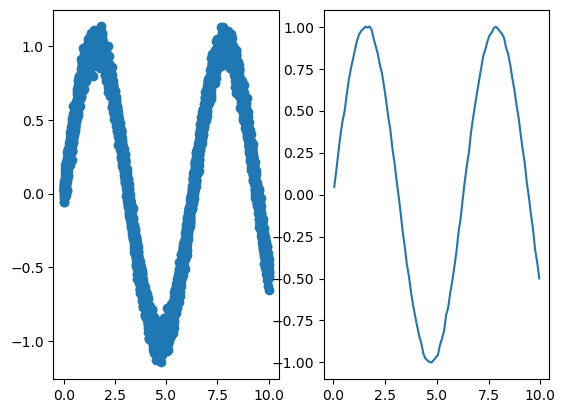

In [609]:
#me
from scipy import stats
x = np.random.uniform(0, 10, size=5000)
y = np.sin(x) + np.random.normal(0, 0.05, size=5000)
df = pd.DataFrame({'x': x, 'y': y})
#df = df.sort_values(by='x', ascending=True)

#plt.plot(df['x'], df['y'], ls='-', marker='')

df['x_bin'] = pd.cut(df['x'], bins=100)
y_stats = df.groupby('x_bin')['y'].agg(['mean', 'std', 'size'])

x_centers = [interval.mid for interval in y_stats.index]

res_pear = stats.pearsonr(df['x'], df['y'])
res_spear = stats.spearmanr(df['x'], df['y'])

print(res_pear)
print(res_spear)

fig, ax = plt.subplots(1, 2)
ax[0].scatter(df['x'], df['y'])
ax[1].plot(x_centers, y_stats['mean'])

# Exercice 3

Contexte

Tu veux séparer deux populations mélangées.

Données

Deux gaussiennes partiellement superposées

Une variable x

Une étiquette vraie (connue pour la simulation)

Travail demandé

Construire le DataFrame

Trouver le seuil optimal qui minimise l’erreur

Calculer :

taux de faux positifs

taux de faux négatifs

Visualiser :

histogrammes superposés

seuil optimal

In [643]:
#me
sample1_data = np.random.normal(0, 1, size=2500)
sample1_label = ['sample1'] * len(sample1_data)
sample1_label = np.array(sample1_label)

sample2_data = np.random.normal(5, 1, size=2500)
sample2_label = ['sample2'] * len(sample2_data)
sample2_label = np.array(sample2_label)

x = np.append(sample1_data, sample2_data)
label = np.append(sample1_label, sample2_label)

df = pd.DataFrame({'x': x, 'label': label})


best_error = 0
for j in range(-10, 10):
    test = []
    for i in range(len(df['x'])):
        thresh = j
        if df['x'][i] < thresh:
            test.append('sample1')
        if df['x'][i] >= thresh:
            test.append('sample2')

    df['test'] = test

    dfreals1 = df[df['label'] == 'sample1']
    dfths1 = df[df['test'] == 'sample1']
    
    if np.abs(len(dfreals1) - len(dfths1)) < best_error:
        best_error = np.abs(len(dfreals1) - len(dfths1))
        best_thres = thresh
print(best_error, best_thres)
        






0 8


0       1
1       1
2       1
3       1
4       1
       ..
4995    1
4996    1
4997    1
4998    1
4999    1
Name: x, Length: 5000, dtype: int64
0       1
1       1
2       1
3       1
4       1
       ..
4995    1
4996    1
4997    1
4998    1
4999    1
Name: x, Length: 5000, dtype: int64
0       1
1       1
2       1
3       1
4       1
       ..
4995    1
4996    1
4997    1
4998    1
4999    1
Name: x, Length: 5000, dtype: int64
0       1
1       1
2       1
3       1
4       1
       ..
4995    1
4996    1
4997    1
4998    1
4999    1
Name: x, Length: 5000, dtype: int64
0       1
1       1
2       1
3       1
4       1
       ..
4995    1
4996    1
4997    1
4998    1
4999    1
Name: x, Length: 5000, dtype: int64
0       1
1       1
2       1
3       1
4       1
       ..
4995    1
4996    1
4997    1
4998    1
4999    1
Name: x, Length: 5000, dtype: int64
0       1
1       1
2       1
3       1
4       1
       ..
4995    1
4996    1
4997    1
4998    1
4999    1
Name: x, Lengt

0       0
1       0
2       0
3       0
4       0
       ..
4995    0
4996    0
4997    0
4998    0
4999    0
Name: x, Length: 5000, dtype: int64
0       0
1       0
2       0
3       0
4       0
       ..
4995    0
4996    0
4997    0
4998    0
4999    0
Name: x, Length: 5000, dtype: int64
0       0
1       0
2       0
3       0
4       0
       ..
4995    0
4996    0
4997    0
4998    0
4999    0
Name: x, Length: 5000, dtype: int64
0       0
1       0
2       0
3       0
4       0
       ..
4995    0
4996    0
4997    0
4998    0
4999    0
Name: x, Length: 5000, dtype: int64
0       0
1       0
2       0
3       0
4       0
       ..
4995    0
4996    0
4997    0
4998    0
4999    0
Name: x, Length: 5000, dtype: int64
0       0
1       0
2       0
3       0
4       0
       ..
4995    0
4996    0
4997    0
4998    0
4999    0
Name: x, Length: 5000, dtype: int64
0       0
1       0
2       0
3       0
4       0
       ..
4995    0
4996    0
4997    0
4998    0
4999    0
Name: x, Lengt

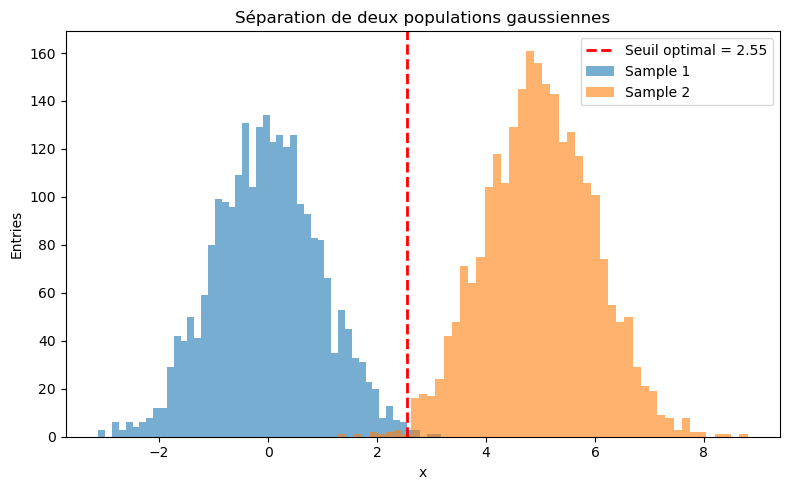

In [646]:
#correction
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Génération des données
# =========================
np.random.seed(0)

sample1_data = np.random.normal(loc=0, scale=1, size=2500)
sample2_data = np.random.normal(loc=5, scale=1, size=2500)

x = np.concatenate([sample1_data, sample2_data])
label_true = np.concatenate([
    np.zeros(len(sample1_data)),   # sample1 -> 0
    np.ones(len(sample2_data))      # sample2 -> 1
])

df = pd.DataFrame({
    'x': x,
    'label_true': label_true
})

# =========================
# 2. Recherche du seuil optimal
# =========================
thresholds = np.linspace(-3, 8, 1000)

best_error = np.inf
best_thresh = None

for thresh in thresholds:
    pred = (df['x'] >= thresh).astype(int)
    print(pred)
    errors = np.sum(pred != df['label_true'])

    if errors < best_error:
        best_error = errors
        best_thresh = thresh

print(f"Seuil optimal : {best_thresh:.3f}")
print(f"Nombre d'erreurs minimales : {best_error}")

# =========================
# 3. Faux positifs / faux négatifs
# =========================
df['pred'] = (df['x'] >= best_thresh).astype(int)

TP = np.sum((df['pred'] == 1) & (df['label_true'] == 1))
TN = np.sum((df['pred'] == 0) & (df['label_true'] == 0))
FP = np.sum((df['pred'] == 1) & (df['label_true'] == 0))
FN = np.sum((df['pred'] == 0) & (df['label_true'] == 1))

fp_rate = FP / (FP + TN)
fn_rate = FN / (FN + TP)

print(f"Taux de faux positifs : {fp_rate:.3f}")
print(f"Taux de faux négatifs : {fn_rate:.3f}")

# =========================
# 4. Visualisation
# =========================
plt.figure(figsize=(8, 5))

plt.hist(sample1_data, bins=50, alpha=0.6, label='Sample 1')
plt.hist(sample2_data, bins=50, alpha=0.6, label='Sample 2')

plt.axvline(best_thresh, color='red', linestyle='--', linewidth=2,
            label=f'Seuil optimal = {best_thresh:.2f}')

plt.xlabel('x')
plt.ylabel('Entries')
plt.title('Séparation de deux populations gaussiennes')
plt.legend()
plt.tight_layout()
plt.show()


# Exercice 4
Contexte

Tu analyses un signal bruité contenant plusieurs fréquences.

Données

signal temporel

deux fréquences dominantes

bruit blanc

Travail demandé

Générer le signal

Calculer la FFT

Identifier les pics fréquentiels

Filtrer le signal

Comparer signal brut vs filtré

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_48274/1658477673.py:15: RuntimeWarning: divide by zero encountered in divide
  plt.plot(1/t, np.abs(fft_signal))


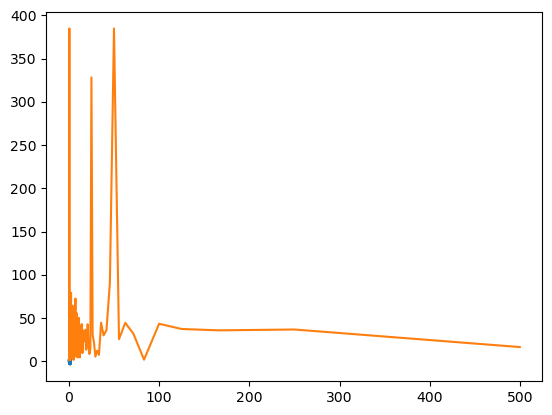

In [661]:
import math
from scipy.fftpack import fft, ifft

N=1000
t = np.linspace(0, 2, N)

f1 = 5
f2 = 10

signal = 0.8 * np.sin(2*math.pi*f1*t) + 0.6 * np.sin(2*math.pi*f2*t) + np.random.normal(0, 1, size=N)
plt.plot(t, signal)

fft_signal = fft(signal)
#print(fft_signal)
plt.plot(1/t, np.abs(fft_signal))



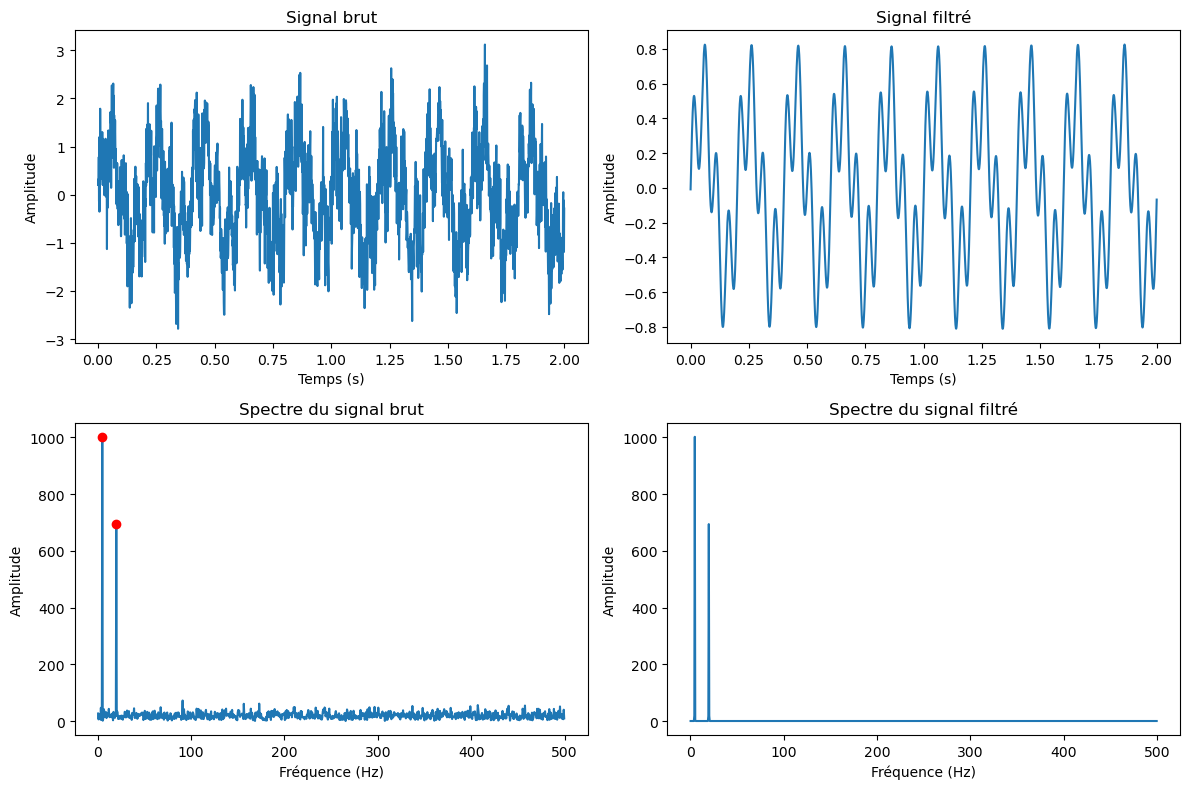

Fréquences dominantes détectées (Hz) :
[ 5. 20.]


In [662]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ===============================
# 1️⃣ Génération du signal
# ===============================

fs = 1000            # fréquence d'échantillonnage (Hz)
T = 2.0              # durée du signal (s)
t = np.linspace(0, T, int(fs*T), endpoint=False)

f1 = 5               # fréquence 1 (Hz)
f2 = 20              # fréquence 2 (Hz)

signal_clean = (
    np.sin(2*np.pi*f1*t) +
    0.7 * np.sin(2*np.pi*f2*t)
)

noise = np.random.normal(0, 0.5, size=len(t))
signal = signal_clean + noise

# ===============================
# 2️⃣ FFT du signal
# ===============================

fft_vals = np.fft.fft(signal)
freqs = np.fft.fftfreq(len(fft_vals), 1/fs)

mask = freqs > 0     # on garde les fréquences positives
freqs_pos = freqs[mask]
fft_mag = np.abs(fft_vals[mask])

# ===============================
# 3️⃣ Identification des pics fréquentiels
# ===============================

peaks, _ = find_peaks(fft_mag, height=np.max(fft_mag)*0.2)
dominant_freqs = freqs_pos[peaks]

# ===============================
# 4️⃣ Filtrage fréquentiel
# ===============================

fft_filtered = fft_vals.copy()

for i, f in enumerate(freqs):
    if not any(np.abs(f - dominant_freqs) < 1):
        fft_filtered[i] = 0

signal_filtered = np.fft.ifft(fft_filtered).real

# ===============================
# 5️⃣ Visualisations
# ===============================

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Signal temporel brut
ax[0, 0].plot(t, signal)
ax[0, 0].set_title("Signal brut")
ax[0, 0].set_xlabel("Temps (s)")
ax[0, 0].set_ylabel("Amplitude")

# Signal temporel filtré
ax[0, 1].plot(t, signal_filtered)
ax[0, 1].set_title("Signal filtré")
ax[0, 1].set_xlabel("Temps (s)")
ax[0, 1].set_ylabel("Amplitude")

# Spectre avant filtrage
ax[1, 0].plot(freqs_pos, fft_mag)
ax[1, 0].plot(freqs_pos[peaks], fft_mag[peaks], "ro")
ax[1, 0].set_title("Spectre du signal brut")
ax[1, 0].set_xlabel("Fréquence (Hz)")
ax[1, 0].set_ylabel("Amplitude")

# Spectre après filtrage
ax[1, 1].plot(freqs_pos, np.abs(fft_filtered[mask]))
ax[1, 1].set_title("Spectre du signal filtré")
ax[1, 1].set_xlabel("Fréquence (Hz)")
ax[1, 1].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

# ===============================
# Résultat final
# ===============================

print("Fréquences dominantes détectées (Hz) :")
print(np.round(dominant_freqs, 2))


# Exercice 5
Contexte

Tu as 4 variables à représenter simultanément.

Données

x, y, z, intensité

Travail demandé

Construire un DataFrame

Créer un scatter :

x vs y

couleur = z

taille = intensité

Ajouter :

légende de taille

colorbar propre

Rendre le plot lisible (clipping, alpha, aspect)


0        18.339927
1       114.960526
2       105.069042
3        23.670333
4        70.097786
           ...    
2995    241.982648
2996     46.513997
2997     17.870379
2998     46.883196
2999    119.023235
Name: intensity, Length: 3000, dtype: float64
0        20.000000
1       114.960526
2       105.069042
3        23.670333
4        70.097786
           ...    
2995    220.000000
2996     46.513997
2997     20.000000
2998     46.883196
2999    119.023235
Name: intensity, Length: 3000, dtype: float64


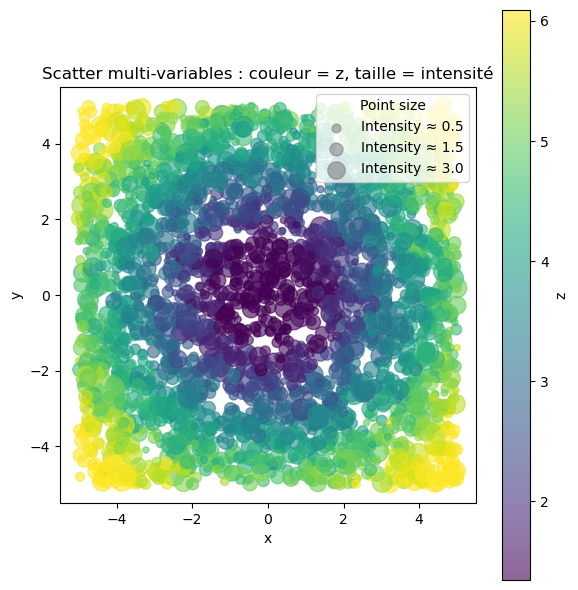

In [665]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Génération des données
# =========================
np.random.seed(0)

n = 3000

x = np.random.uniform(-5, 5, n)
y = np.random.uniform(-5, 5, n)
z = np.sqrt(x**2 + y**2) + np.random.normal(0, 0.3, n)   # variable continue
intensity = np.random.exponential(scale=1.5, size=n)    # variable positive

df = pd.DataFrame({
    'x': x,
    'y': y,
    'z': z,
    'intensity': intensity
})

# =========================
# 2) Paramètres d'affichage
# =========================

# Clipping pour éviter les outliers visuels
z_min, z_max = np.percentile(df['z'], [5, 95])
i_min, i_max = np.percentile(df['intensity'], [5, 95])

# Normalisation taille des points
sizes = 20 + 200 * (df['intensity'] - i_min) / (i_max - i_min)
print(sizes)
sizes = np.clip(sizes, 20, 220)
print(sizes)
# =========================
# 3) Scatter plot
# =========================
fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(
    df['x'],
    df['y'],
    c=df['z'],
    s=sizes,
    cmap='viridis',
    alpha=0.6,
    vmin=z_min,
    vmax=z_max
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Scatter multi-variables : couleur = z, taille = intensité')
ax.set_aspect('equal')

# =========================
# 4) Colorbar propre
# =========================
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('z')

# =========================
# 5) Légende de taille
# =========================
size_levels = [0.5, 1.5, 3.0]
handles = []

for s in size_levels:
    handles.append(
        plt.scatter(
            [], [], 
            s=20 + 200 * (s - i_min) / (i_max - i_min),
            color='gray',
            alpha=0.6,
            label=f'Intensity ≈ {s}'
        )
    )

ax.legend(
    handles=handles,
    title='Point size',
    loc='upper right',
    frameon=True
)

plt.tight_layout()
plt.show()


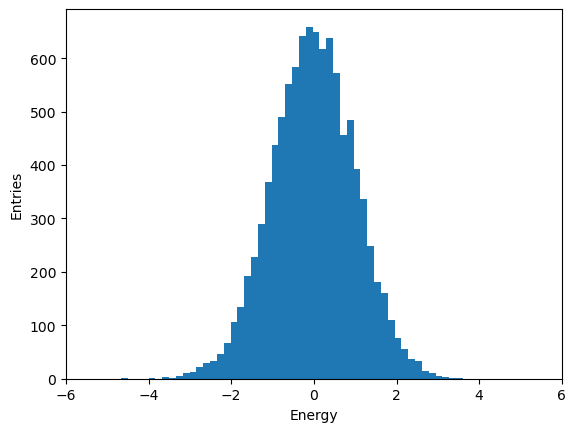

(array([-3.8, -3.4, -3. , -2.6, -2.2, -1.8, -1.4, -1. , -0.6, -0.2,  0.2,
        0.6,  1. ,  1.4,  1.8,  2.2,  2.6,  3. ,  3.4,  3.8]), array([4.97886542, 5.00816911, 4.95918092, 5.02010712, 5.00036886,
       4.99274552, 4.99439135, 5.01230339, 5.00070926, 4.99711252,
       4.99404864, 5.02833901, 5.00900162, 5.00506182, 5.00203999,
       4.97912723, 4.996836  , 5.03076529, 4.98031588, 4.99410492]), array([0.01412345, 0.01442437, 0.01419041, 0.01417545, 0.01417229,
       0.01412078, 0.01405292, 0.01427932, 0.0145561 , 0.01406968,
       0.01404528, 0.01400852, 0.01446519, 0.01387623, 0.01411821,
       0.01422277, 0.01435972, 0.01429583, 0.01438297, 0.01401573]))


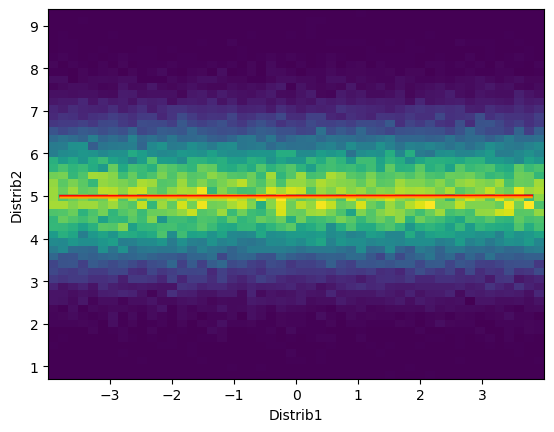

In [718]:
import invisible_cities.core.fit_functions as fitf
energy1 = np.random.normal(0, 1, size=100000)
energy2 = np.random.normal(5, 1, size=100000)
flat = np.random.uniform(-4, 4, size=100000)

plt.hist(energy, bins=50)
plt.xlabel('Energy')
plt.ylabel('Entries')
plt.xlim(-6, 6)
plt.show()

#plt.hist2d(energy1, energy2, bins=50)
#plt.xlabel('Distrib1')
#plt.ylabel('Distrib2')

h = plt.hist2d(flat, energy2, bins=50)
plt.xlabel('Distrib1')
plt.ylabel('Distrib2')

tprof = fitf.profileX(flat, energy2, xrange=[-10, 10], yrange=[0, 10], nbins=50)
print(tprof)
x = tprof[0]
y = tprof[1]

popt, pcov = np.polyfit(x, y, deg=1, cov=True)
a, b = popt
y_lin = a * x + b
res = y - y_lin
sigma = np.std(res)

plt.plot(x, y_lin, '-', color='red', linewidth=2)

plt.plot(x, y_lin - 2*sigma, color='orange')

        

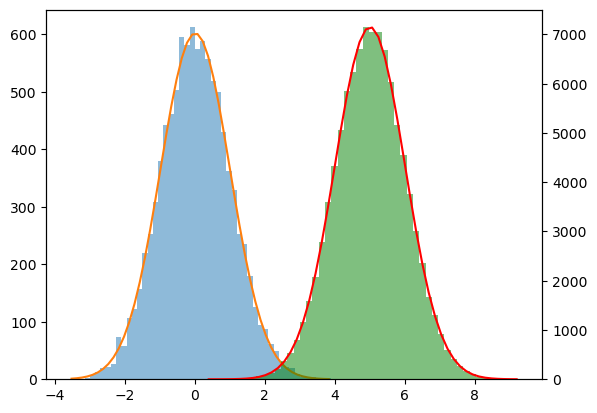

In [699]:
from scipy.optimize import curve_fit
def gauss(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

data = [energy1]
fig, ax1 = plt.subplots()

for i in range(len(data)):
    distrib = data[i]
    
    n, bins, patches = ax1.hist(distrib, bins=50, alpha = 0.5)

    bin_centers = (bins[1:] + bins[:-1]) / 2
    

    p0 = (400, 0, 5)

    popt, pcov = curve_fit(gauss, bin_centers, n, p0=p0)

    y_fit = gauss(bin_centers, *popt)

    ax1.plot(bin_centers, y_fit)
    
ax2 = ax1.twinx()
data = [energy2]

for i in range(len(data)):
    distrib = data[i]

    n, bins, patches = ax2.hist(distrib, bins=50, alpha = 0.5, color='green')

    bin_centers = (bins[1:] + bins[:-1]) / 2


    p0 = (400, 0, 5)

    popt, pcov = curve_fit(gauss, bin_centers, n, p0=p0)

    y_fit = gauss(bin_centers, *popt)

    ax2.plot(bin_centers, y_fit, color='red')
    


